# TrueRender v2 — Upgraded Pipeline

| Stage | Tool | Status |
|---|---|---|
| 1. Frame extract + filter | ffmpeg + Laplacian | ✅ done |
| 2. Object detection | Grounding DINO | ✅ implemented |
| 3. Masking | SAM 3 | 🔜 next |
| 4. Geometry | VGGT | 🔜 |
| 5. Splat training | 2DGS | 🔜 |
| 6. Mesh extract | TSDF | 🔜 |
| 7. Export | trimesh GLB/STL/OBJ | 🔜 |

**v1 backup:** `reconstruction_v1.ipynb` — kept intact for ablation study.

## Setup
Run once per Colab session.

In [1]:
!pip install -q opencv-python-headless matplotlib
print("Done")

Done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Stage 1 — Frame Extraction + Quality Filter

Extract raw frames at 5 fps, then keep the **30 sharpest** by variance-of-Laplacian.
Blurry frames hurt geometry estimation — this filter is free and cuts 57% of frames,
directly reducing compute in every downstream stage.

In [3]:
import cv2, glob, shutil, os, time

VIDEO_PATH  = "/content/drive/MyDrive/hydroflaskgreen.MOV"
FRAMES_RAW  = "/content/frames_raw"
FRAMES_KEEP = "/content/frames"
N_KEEP      = 30

os.makedirs(FRAMES_RAW,  exist_ok=True)
os.makedirs(FRAMES_KEEP, exist_ok=True)

t0 = time.time()

# Extract raw frames
!ffmpeg -i "{VIDEO_PATH}" -vf fps=5 "{FRAMES_RAW}/frame_%05d.jpg" -y -loglevel error

all_frames = sorted(glob.glob(f"{FRAMES_RAW}/*.jpg"))
print(f"Raw frames extracted: {len(all_frames)}")

# Score by variance-of-Laplacian (higher = sharper)
scored = [
    (f, cv2.Laplacian(cv2.imread(f, cv2.IMREAD_GRAYSCALE), cv2.CV_64F).var())
    for f in all_frames
]
scored.sort(key=lambda x: -x[1])

# Keep N_KEEP sharpest, re-sort by filename to preserve temporal order
keep = sorted([f for f, _ in scored[:N_KEEP]])
for dst_idx, src in enumerate(keep):
    shutil.copy(src, f"{FRAMES_KEEP}/frame_{dst_idx:05d}.jpg")

t1 = time.time()
print(f"Kept {len(keep)} / {len(all_frames)} frames")
print(f"Sharpness — best: {scored[0][1]:.1f}  cutoff: {scored[N_KEEP-1][1]:.1f}  worst dropped: {scored[-1][1]:.1f}")
print(f"Stage 1 wall time: {t1 - t0:.1f}s")

Raw frames extracted: 70
Kept 30 / 70 frames
Sharpness — best: 199.0  cutoff: 48.9  worst dropped: 14.4
Stage 1 wall time: 3.4s


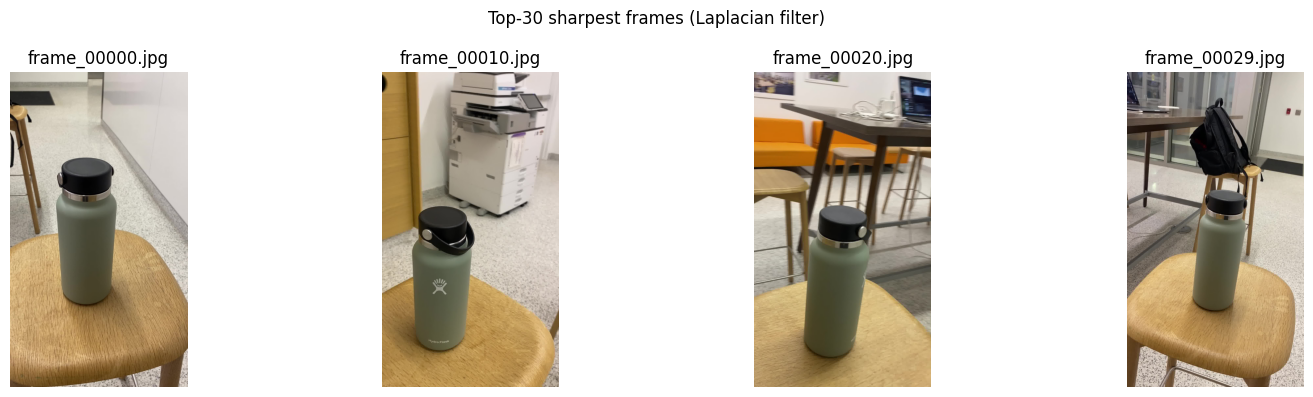

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

frames = sorted(os.listdir(FRAMES_KEEP))
indices = [0, len(frames)//3, 2*len(frames)//3, -1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, indices):
    ax.imshow(mpimg.imread(f"{FRAMES_KEEP}/{frames[i]}"))
    ax.set_title(frames[i])
    ax.axis("off")
plt.suptitle(f"Top-{N_KEEP} sharpest frames (Laplacian filter)", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# Checkpoint to Drive — so a fresh session can skip re-extraction
DRIVE_FRAMES = "/content/drive/MyDrive/truerender_frames_v2"
if os.path.exists(DRIVE_FRAMES):
    shutil.rmtree(DRIVE_FRAMES)
shutil.copytree(FRAMES_KEEP, DRIVE_FRAMES)
print(f"Checkpointed {len(os.listdir(DRIVE_FRAMES))} frames → Drive")

Checkpointed 30 frames → Drive


## Stage 2 — Object Detection (Grounding DINO)

Runs on **frame 0** only. Uses a broad caption to detect all salient objects,
then scores each detection by **confidence − 0.5 × normalized center distance**.
The winner's label becomes the SAM 3 prompt in Stage 3.

**Toggle:** set  to skip detection and supply your own prompt.

In [6]:
import os

# transformers>=4.40 breaks groundingdino-py; pin to last known-good version
!pip install -q "transformers==4.38.2"
!pip install -q groundingdino-py

DINO_WEIGHTS = "/content/groundingdino_swint_ogc.pth"
DINO_URL = "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha2/groundingdino_swint_ogc.pth"

def _weights_ok():
    return os.path.exists(DINO_WEIGHTS) and os.path.getsize(DINO_WEIGHTS) > 150e6

if not _weights_ok():
    if os.path.exists(DINO_WEIGHTS):
        os.remove(DINO_WEIGHTS)  # remove corrupt/partial file
    !wget -q --show-progress -O {DINO_WEIGHTS} {DINO_URL}

assert _weights_ok(), f"Weights download failed or corrupt: {os.path.getsize(DINO_WEIGHTS)/1e6:.1f} MB"
print(f"Weights OK: {os.path.getsize(DINO_WEIGHTS)/1e6:.1f} MB")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 83.2 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.7 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
Weights already present: /content/groundingdino_swint_ogc.pth


Config: /usr/local/lib/python3.12/dist-packages/groundingdino/config/GroundingDINO_SwinT_OGC.py
final text_encoder_type: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:962: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/usr/local/lib/python3.12/dist-packages/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args

Detected 5 object(s):
  [0] 'bottle container'  conf=0.397  score=0.326 <- selected
  [1] 'object item'  conf=0.315  score=-0.221
  [2] 'object item'  conf=0.340  score=-0.101
  [3] 'product'  conf=0.323  score=0.252
  [4] 'bottle cup'  conf=0.312  score=0.241

target_object = 'bottle container'
Stage 2 wall time: 8.2s


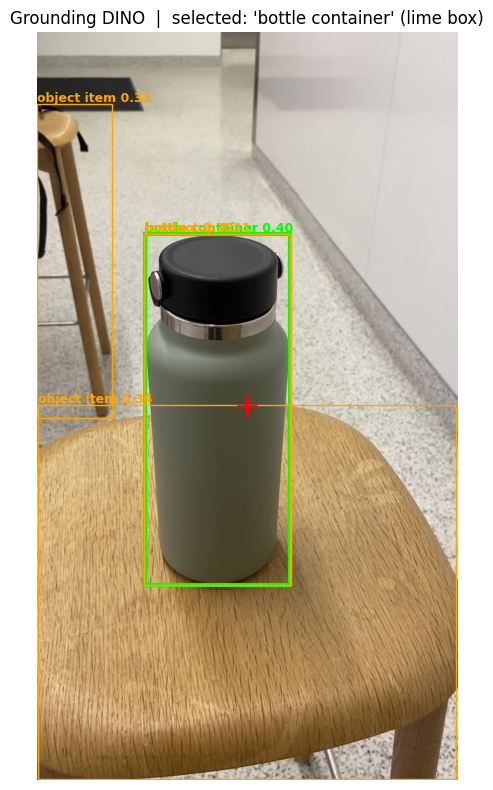

In [12]:
import time
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from groundingdino.util.inference import load_model, load_image, predict

# ── Toggles ──────────────────────────────────────────────────────────────────
AUTO_SELECT   = True                   # False -> skip DINO, use MANUAL_PROMPT
MANUAL_PROMPT = "green hydroflask"     # only used when AUTO_SELECT = False

DINO_CAPTION  = "object . bottle . container . cup . box . item . product"
BOX_THRESHOLD = 0.3
TXT_THRESHOLD = 0.25
FRAMES_KEEP   = "/content/frames"      # set by Stage 1; re-assign if resuming
DINO_WEIGHTS  = "/content/groundingdino_swint_ogc.pth"
# ─────────────────────────────────────────────────────────────────────────────

t0 = time.time()

FIRST_FRAME = f"{FRAMES_KEEP}/frame_00000.jpg"

if AUTO_SELECT:
    import groundingdino, os
    DINO_CONFIG = os.path.join(
        os.path.dirname(groundingdino.__file__),
        "config", "GroundingDINO_SwinT_OGC.py"
    )
    print(f"Config: {DINO_CONFIG}")

    dino = load_model(
        DINO_CONFIG,
        DINO_WEIGHTS,
    )
    image_source, image = load_image(FIRST_FRAME)
    boxes, logits, phrases = predict(
        model=dino,
        image=image,
        caption=DINO_CAPTION,
        box_threshold=BOX_THRESHOLD,
        text_threshold=TXT_THRESHOLD,
    )

    if len(boxes) == 0:
        raise RuntimeError(
            "Grounding DINO found no objects. "
            "Try lowering BOX_THRESHOLD, or set AUTO_SELECT=False and supply MANUAL_PROMPT."
        )

    h, w = image_source.shape[:2]

    def rank_score(i):
        cx = boxes[i][0].item() * w
        cy = boxes[i][1].item() * h
        dist_norm = ((cx - w/2)**2 + (cy - h/2)**2)**0.5 / (w / 2)
        return logits[i].item() - 0.5 * dist_norm

    best_idx      = max(range(len(boxes)), key=rank_score)
    target_object = phrases[best_idx]

    t1 = time.time()
    print(f"Detected {len(boxes)} object(s):")
    for i, (p, l) in enumerate(zip(phrases, logits)):
        marker = " <- selected" if i == best_idx else ""
        print(f"  [{i}] {repr(p)}  conf={l.item():.3f}  score={rank_score(i):.3f}{marker}")
    print()
    print(f"target_object = {repr(target_object)}")
    print(f"Stage 2 wall time: {t1 - t0:.1f}s")

    # Visualize
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_source)
    for i, (box, phrase, logit) in enumerate(zip(boxes, phrases, logits)):
        cx_px = box[0].item() * w
        cy_px = box[1].item() * h
        bw_px = box[2].item() * w
        bh_px = box[3].item() * h
        color = "lime" if i == best_idx else "orange"
        lw    = 3     if i == best_idx else 1
        ax.add_patch(patches.Rectangle(
            (cx_px - bw_px/2, cy_px - bh_px/2), bw_px, bh_px,
            linewidth=lw, edgecolor=color, facecolor="none"
        ))
        ax.text(
            cx_px - bw_px/2, cy_px - bh_px/2 - 5,
            f"{phrase} {logit.item():.2f}",
            color=color, fontsize=9, fontweight="bold"
        )
    ax.plot(w/2, h/2, "+", color="red", markersize=15, markeredgewidth=2)
    ax.set_title(f"Grounding DINO  |  selected: {repr(target_object)} (lime box)", fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    target_object = MANUAL_PROMPT
    t1 = time.time()
    print(f"Manual mode  target_object = {repr(target_object)}")
    print(f"Stage 2 wall time: {t1 - t0:.1f}s")


In [11]:
import os
DINO_WEIGHTS = "/content/groundingdino_swint_ogc.pth"
if os.path.exists(DINO_WEIGHTS):
    os.remove(DINO_WEIGHTS)

!wget -q --show-progress -O {DINO_WEIGHTS} \
    "https://huggingface.co/ShilongLiu/GroundingDINO/resolve/main/groundingdino_swint_ogc.pth"

size_mb = os.path.getsize(DINO_WEIGHTS) / 1e6
print(f"Downloaded: {size_mb:.1f} MB")


/content/groundingd 100%[===================>] 661.85M   433MB/s    in 1.5s    
Downloaded: 694.0 MB
